# Set-up

In [507]:
# Importing libraries
import os
import glob
import json
import torch
import random

import pyfaidx
import numpy as np
import pandas as pd
import pyBigWig

import seqpro as sp

from tangermeme.io import extract_loci
from bpnetlite.bpnet import BPNet, CountWrapper, ProfileWrapper, ControlWrapper, _ProfileLogitScaling
from tangermeme.predict import predict
from tangermeme.deep_lift_shap import deep_lift_shap, _nonlinear
from tangermeme.plot import plot_logo

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# Set scanpy and matplotlib styles for publication
matplotlib.rcParams.update({
    "axes.linewidth": 0.5,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.major.size": 0,
    "ytick.major.size": 0,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

In [514]:
def log_softmax_profile(
    y_profile,
):
    # Log softmax the predicted profile
    z = y_profile.shape
    y_profile = y_profile.reshape(y_profile.shape[0], -1)
    y_profile = torch.nn.functional.log_softmax(y_profile, dim=-1)
    y_profile = y_profile.reshape(*z)
    return y_profile


def plot_tracks(
    tracks,
    interval,
    height=1.5,
    width=20,
    colors=None,
    ylims=None,
    sharey=False,
    highlights=None,
    highlight_colors=None,
    hspace=0.15,
    label=True
):
    _, axes = plt.subplots(len(tracks), 1, figsize=(width, height * len(tracks)), sharex=True, sharey=sharey)
    if not isinstance(axes, np.ndarray):
        axes = [axes]

    for ax, (title, y) in zip(axes, tracks.items()):
        x = np.linspace(interval["start"], interval["end"], num=len(y))
        color = colors[title] if colors is not None and title in colors else None
        fb = ax.fill_between(x, y, color=color)
        fb.set_rasterized(True)  # Rasterize the fill for better performance

        # Apply user-defined y-limits if provided
        if ylims is not None and title in ylims:
            print(f"Setting ylims for {title} to {ylims[title]}")
            ax.set_ylim(ylims[title])

        # Add highlights
        if highlights is not None:
            for i, (h_start, h_end) in enumerate(highlights):
                h_color = (
                    highlight_colors[i]
                    if highlight_colors is not None and i < len(highlight_colors)
                    else "yellow"
                )
                ax.axvspan(h_start, h_end, color=h_color, alpha=0.3)

        # Add track label text
        if label:
            ylims_ = ax.get_ylim()
            ax.text(
                interval["end"] - (interval["end"] - interval["start"]) * 0.05,
                (ylims_[0] + ylims_[1]) / 2,
                title,
                va='center',
                ha='left',
                fontsize=9,
            )
        sns.despine(top=True, right=True, bottom=True)
    ax.set_xlabel(f"{interval['chrom']}:{interval['start']}-{interval['end']}")
    plt.subplots_adjust(hspace=hspace)
    plt.tight_layout()

In [255]:
def get_input_intervals(chrom, start, end, model_in_len=2114, model_out_len=1000):
    """
    Given a genomic interval and model parameters, return a list of input sequence intervals
    (of size `model_in_len`) to tile the desired output region using non-overlapping output windows.
    """
    total_out_len = end - start
    assert total_out_len % model_out_len == 0, "Desired region must be divisible by output window size"
    num_tiles = total_out_len // model_out_len

    input_intervals = []
    for i in range(num_tiles):
        out_start = start + i * model_out_len
        out_center = out_start + model_out_len // 2
        in_start = out_center - model_in_len // 2
        in_end = in_start + model_in_len
        input_intervals.append((chrom, in_start, in_end))
    return input_intervals

In [467]:
celltype = "SC.beta"
condition = "3-cyt"

model_in_len = 2114
model_out_len = 1000

out_window = 100_000

# Load genome

In [468]:
# Load genome
chrom_sizes = "/cellar/users/aklie/data/ref/genomes/hg38/hg38.chrom.sizes"
chrom_sizes = pd.read_csv(chrom_sizes, header=None, sep='\t', names=['chrom', 'size'])
chrom_sizes_dict = chrom_sizes.set_index('chrom')['size'].to_dict()

genome_fasta = "/cellar/users/aklie/data/ref/genomes/hg38/hg38.fa"
genome = pyfaidx.Fasta(genome_fasta)

# Load loci

In [469]:
conditions = ["3-cyt", "IFNg", "Ex-4_HG", "palmitate"]

In [470]:
results = []
for condition in conditions:
    path_deseq2_res = f"/cellar/users/aklie/data/datasets/igvf_sc-islet_10X-Multiome/results/7_differential_analysis/atac/deseq2/pseudobulk/{celltype}/{condition}/deseq2_results.tsv"
    res = pd.read_csv(path_deseq2_res, sep="\t")
    res["condition"] = condition
    res_filt = res[res["contrast"] == "LRT-condition:timepoint"]
    res_filt = res_filt[res_filt["padj"] < 0.05]
    res_filt.sort_values("padj", inplace=True)
    res_filt = res_filt[res_filt["baseMean"] > 10]
    results.append(res_filt)

In [471]:
results = pd.concat(results, ignore_index=True)
results["chrom"] = results["feature"].apply(lambda x: x.split(":")[0])
results["start"] = results["feature"].apply(lambda x: int(x.split(":")[1].split("-")[0]))
results["end"] = results["feature"].apply(lambda x: int(x.split(":")[1].split("-")[1]))

In [472]:
# Take the top 10 up and down peaks for each condition
top_n = 10
top_peaks = []
for condition in conditions:
    res_cond = results[results["condition"] == condition]
    top_up = res_cond.nlargest(top_n, "log2FoldChange")
    top_down = res_cond.nsmallest(top_n, "log2FoldChange")
    top_peaks.append(top_up)
    top_peaks.append(top_down)
top_peaks = pd.concat(top_peaks, ignore_index=True)
top_peaks.reset_index(drop=True, inplace=True)

In [473]:
obs_bw_dict = {
    f"{celltype}_control": f"/cellar/users/aklie/data/datasets/igvf_sc-islet_10X-Multiome/results/4_integration/atac/pseudobulk/rna_celltype+condition/12-1/norm_bws/{celltype}_control.fpm.bw",
    f"{celltype}_3-cyt": f"/cellar/users/aklie/data/datasets/igvf_sc-islet_10X-Multiome/results/4_integration/atac/pseudobulk/rna_celltype+condition/12-1/norm_bws/{celltype}_3-cyt.fpm.bw",
    f"{celltype}_IFNg": f"/cellar/users/aklie/data/datasets/igvf_sc-islet_10X-Multiome/results/4_integration/atac/pseudobulk/rna_celltype+condition/12-1/norm_bws/{celltype}_IFNg.fpm.bw",
    f"{celltype}_Ex-4_HG": f"/cellar/users/aklie/data/datasets/igvf_sc-islet_10X-Multiome/results/4_integration/atac/pseudobulk/rna_celltype+condition/12-1/norm_bws/{celltype}_Ex-4_HG.fpm.bw",
    f"{celltype}_palmitate": f"/cellar/users/aklie/data/datasets/igvf_sc-islet_10X-Multiome/results/4_integration/atac/pseudobulk/rna_celltype+condition/12-1/norm_bws/{celltype}_palmitate.fpm.bw",
}

In [474]:
# Find any peaks that are within 20kb of each other
def find_nearby_peaks(peaks, max_distance=100_000_000):
    nearby_peaks = []
    for i, peak in peaks.iterrows():
        chrom, start, end = peak["chrom"], peak["start"], peak["end"]
        for j, other_peak in peaks.iterrows():
            if i != j and other_peak["chrom"] == chrom:
                other_start, other_end = other_peak["start"], other_peak["end"]
                if abs(start - other_end) <= max_distance or abs(end - other_start) <= max_distance:
                    nearby_peaks.append((peak, other_peak))
    # turn into a DataFrame for just "feature" columns
    nearby_peaks = [(p1["feature"], p2["feature"]) for p1, p2 in nearby_peaks]
    nearby_peaks = pd.DataFrame(nearby_peaks, columns=["peak1", "peak2"])
    return nearby_peaks
nearby_peaks = find_nearby_peaks(top_peaks)
nearby_peaks

,peak1,peak2
0,chr13:49146757-49147258,chr13:49146757-49147258
1,chr6:116695337-116695838,chr6:29561027-29561528
2,chr6:116695337-116695838,chr6:116695337-116695838
3,chr6:116695337-116695838,chr6:51827611-51828112
4,chr18:56248570-56249071,chr18:2641517-2642018
...,...,...
87,chr5:96199650-96200151,chr5:49601332-49601833
88,chr5:96199650-96200151,chr5:147835295-147835796
89,chr5:96199650-96200151,chr5:176658791-176659292
90,chr5:96199650-96200151,chr5:124742085-124742586


# Load sequences and tracks

In [475]:
n_tiles = out_window // model_out_len
in_window = model_in_len + (n_tiles - 1) * model_out_len
print(n_tiles, in_window)

100 101114


In [476]:
X, signals = extract_loci(
    loci=top_peaks[["chrom", "start", "end"]],
    sequences=genome_fasta,
    signals=list(obs_bw_dict.values()),
    verbose=True,
    in_window=in_window,
    out_window=out_window,
)
n_msk = X.sum(dim=(1, 2)) == X.shape[-1]
X = X[n_msk]
signals = signals[n_msk]
top_peaks = top_peaks.loc[n_msk.numpy()]
X.shape, signals.shape

Loading Loci: 100%|██████████| 40/40 [00:00<00:00, 85.33it/s]


(torch.Size([38, 4, 101114]), torch.Size([38, 5, 100000]))

In [477]:
# split along the 2nd dimension, which is the number of signals
signals_dict = {k: np.squeeze(v.numpy()) for k, v in zip(obs_bw_dict.keys(), signals.split(1, dim=1))}

# Model predictions

In [478]:
#/cellar/users/aklie/data/datasets/igvf_sc-islet_10X-Multiome/results/8_chrombpnet/rna_celltype+condition_250k/SC.alpha_3-cyt/fold_0/chrombpnet/1.0/models/chrombpnet_nobias.h5
base_path = "/cellar/users/aklie/data/datasets/igvf_sc-islet_10X-Multiome/results/8_chrombpnet/rna_celltype+condition_250k/*/fold_0/chrombpnet/1.0/models/chrombpnet_nobias.h5"

In [479]:
# Keep only the models for the current cell type
paths_models = glob.glob(base_path, recursive=True)
paths_models = [p for p in paths_models if f"{celltype}" in p]
paths_models

['/cellar/users/aklie/data/datasets/igvf_sc-islet_10X-Multiome/results/8_chrombpnet/rna_celltype+condition_250k/SC.beta_Ex-4_HG/fold_0/chrombpnet/1.0/models/chrombpnet_nobias.h5',
 '/cellar/users/aklie/data/datasets/igvf_sc-islet_10X-Multiome/results/8_chrombpnet/rna_celltype+condition_250k/SC.beta_IFNg/fold_0/chrombpnet/1.0/models/chrombpnet_nobias.h5',
 '/cellar/users/aklie/data/datasets/igvf_sc-islet_10X-Multiome/results/8_chrombpnet/rna_celltype+condition_250k/SC.beta_3-cyt/fold_0/chrombpnet/1.0/models/chrombpnet_nobias.h5',
 '/cellar/users/aklie/data/datasets/igvf_sc-islet_10X-Multiome/results/8_chrombpnet/rna_celltype+condition_250k/SC.beta_control/fold_0/chrombpnet/1.0/models/chrombpnet_nobias.h5',
 '/cellar/users/aklie/data/datasets/igvf_sc-islet_10X-Multiome/results/8_chrombpnet/rna_celltype+condition_250k/SC.beta_palmitate/fold_0/chrombpnet/1.0/models/chrombpnet_nobias.h5']

In [480]:
pred_dict = {}
for model_path in paths_models:

    # Extract the cell type and condition from the model path
    celltype_condition = model_path.split("/")[-6] + "_preds"
    print(f"Processing model: {celltype_condition}")

    # Load the model
    model = BPNet.from_chrombpnet(model_path).cuda().eval()

    y_hat = []
    for i in range(n_tiles):
        start = i * model_out_len
        end = start + model_in_len
        print(f"Tile {i}: input[:, :, {start}:{end}] → predicts output {i*model_out_len}:{(i+1)*model_out_len}")
        
        x_tile = X[:, :, start:end].cuda()
        with torch.no_grad():
            prof_pred, count_pred = predict(model, x_tile)

        # Compute y_hat = count * softmax(profile)
        prof_prob = torch.exp(log_softmax_profile(prof_pred))  # shape: (N, 1, model_out_len)
        counts = torch.exp(count_pred).cpu().numpy()[:, 0]      # shape: (N,)
        prof = prof_prob.cpu().numpy()[:, 0, :]                 # shape: (N, model_out_len)
        y_hat_ = prof * counts[:, None]                          # shape: (N, model_out_len)
        y_hat.append(y_hat_)
    y_hat = np.concatenate(y_hat, axis=1)  # shape: (N, model_in_len)

    # Add the predictions to the dictionary
    pred_dict[celltype_condition] = y_hat

Processing model: SC.beta_Ex-4_HG_preds
Tile 0: input[:, :, 0:2114] → predicts output 0:1000
Tile 1: input[:, :, 1000:3114] → predicts output 1000:2000
Tile 2: input[:, :, 2000:4114] → predicts output 2000:3000
Tile 3: input[:, :, 3000:5114] → predicts output 3000:4000
Tile 4: input[:, :, 4000:6114] → predicts output 4000:5000
Tile 5: input[:, :, 5000:7114] → predicts output 5000:6000
Tile 6: input[:, :, 6000:8114] → predicts output 6000:7000
Tile 7: input[:, :, 7000:9114] → predicts output 7000:8000
Tile 8: input[:, :, 8000:10114] → predicts output 8000:9000
Tile 9: input[:, :, 9000:11114] → predicts output 9000:10000
Tile 10: input[:, :, 10000:12114] → predicts output 10000:11000
Tile 11: input[:, :, 11000:13114] → predicts output 11000:12000
Tile 12: input[:, :, 12000:14114] → predicts output 12000:13000
Tile 13: input[:, :, 13000:15114] → predicts output 13000:14000
Tile 14: input[:, :, 14000:16114] → predicts output 14000:15000
Tile 15: input[:, :, 15000:17114] → predicts output 1

In [481]:
pred_dict.keys()

dict_keys(['SC.beta_Ex-4_HG_preds', 'SC.beta_IFNg_preds', 'SC.beta_3-cyt_preds', 'SC.beta_control_preds', 'SC.beta_palmitate_preds'])

In [482]:
pred_dict["SC.beta_3-cyt_preds"].shape

(38, 100000)

# Model contributions

In [483]:
dtype = torch.float64

In [423]:
paths_models

['/cellar/users/aklie/data/datasets/igvf_sc-islet_10X-Multiome/results/8_chrombpnet/rna_celltype+condition_250k/SC.beta_Ex-4_HG/fold_0/chrombpnet/1.0/models/chrombpnet_nobias.h5',
 '/cellar/users/aklie/data/datasets/igvf_sc-islet_10X-Multiome/results/8_chrombpnet/rna_celltype+condition_250k/SC.beta_IFNg/fold_0/chrombpnet/1.0/models/chrombpnet_nobias.h5',
 '/cellar/users/aklie/data/datasets/igvf_sc-islet_10X-Multiome/results/8_chrombpnet/rna_celltype+condition_250k/SC.beta_3-cyt/fold_0/chrombpnet/1.0/models/chrombpnet_nobias.h5',
 '/cellar/users/aklie/data/datasets/igvf_sc-islet_10X-Multiome/results/8_chrombpnet/rna_celltype+condition_250k/SC.beta_control/fold_0/chrombpnet/1.0/models/chrombpnet_nobias.h5',
 '/cellar/users/aklie/data/datasets/igvf_sc-islet_10X-Multiome/results/8_chrombpnet/rna_celltype+condition_250k/SC.beta_palmitate/fold_0/chrombpnet/1.0/models/chrombpnet_nobias.h5']

In [93]:
contrib_dict = {}
for model_path in paths_models:

    # Extract the cell type and condition from the model path
    celltype_condition = model_path.split("/")[-6] + "_contribs"
    print(f"Processing model: {celltype_condition}")

    # Load the model
    model = BPNet.from_chrombpnet(model_path).cuda().eval()
    count_wrapper = CountWrapper(model).cuda().eval()

    # Get contributions
    X_attr = deep_lift_shap(
        count_wrapper.type(dtype), 
        X.type(dtype),
        n_shuffles=20,
        batch_size=16,
        verbose=True,
        warning_threshold=1e-4
    )

    # Add the contributions to the dictionary
    contrib_dict[celltype_condition] = X_attr

Processing model: SC.beta_Ex-4_HG_contribs


100%|██████████| 780/780 [00:29<00:00, 26.47it/s]


Processing model: SC.beta_IFNg_contribs


100%|██████████| 780/780 [00:29<00:00, 26.34it/s]


Processing model: SC.beta_3-cyt_contribs


100%|██████████| 780/780 [00:29<00:00, 26.24it/s]


Processing model: SC.beta_control_contribs


100%|██████████| 780/780 [00:29<00:00, 26.16it/s]


Processing model: SC.beta_palmitate_contribs


100%|██████████| 780/780 [00:29<00:00, 26.11it/s]


In [138]:
# For each contrib_dict vect take the average across the 2nd dim of the vector and crop to middle 1000 and put into a new dict called contrib_magnitude_dict
contrib_magnitude_dict = {}
for k, v in contrib_dict.items():
    start, end = v.shape[2] // 2 - 500, v.shape[2] // 2 + 500
    v = v[:, :, start:end]
    v = v.mean(dim=1)
    v = v.cpu().detach().numpy()
    contrib_magnitude_dict[k] = v

In [139]:
contrib_dict["SC.beta_3-cyt_contribs"].shape

torch.Size([39, 4, 2114])

In [140]:
contrib_magnitude_dict["SC.beta_3-cyt_contribs"].shape

(39, 1000)

# Plot

In [484]:
# Interleave the dicts so that observed and predicted tracks for each cell type and condition are one after another
vals_dict = {}
for k in range(len(signals_dict)):
    key = list(signals_dict.keys())[k]
    vals_dict[f"{key}_obs"] = signals_dict[key]
    vals_dict[f"{key}_pred"] = pred_dict[key + "_preds"]
vals_dict.keys()

dict_keys(['SC.beta_control_obs', 'SC.beta_control_pred', 'SC.beta_3-cyt_obs', 'SC.beta_3-cyt_pred', 'SC.beta_IFNg_obs', 'SC.beta_IFNg_pred', 'SC.beta_Ex-4_HG_obs', 'SC.beta_Ex-4_HG_pred', 'SC.beta_palmitate_obs', 'SC.beta_palmitate_pred'])

In [485]:
colors = {
    "control": "#B0B0B0",
    "3-cyt": "#FFA07A",
    "IFNg": "#FF7F50",
    "Ex-4_HG": "#90EE90",
    "palmitate": "#BA55D3",
}
colors_obs = {f"{celltype}_{k}_obs": v for k, v in colors.items()}
colors_pred = {f"{celltype}_{k}_pred": v for k, v in colors.items()}
colors_contrib = {f"{celltype}_{k}_contribs": v for k, v in colors.items()}

colors_dict = {**colors_obs, **colors_pred, **colors_contrib}

In [486]:
# Make new dictionary with the locus, grabbing the index from each value in vals_dict
index = 1
locus = top_peaks.iloc[index]["feature"]
chrom, coord = locus.split(":")
start, end = coord.split("-")
start, end = int(start) - out_window // 2, int(end) + out_window // 2
locus = f"{chrom}:{start}-{end}"
top_peaks.iloc[index]

baseMean                         10.367924
log2FoldChange                    3.603297
lfcSE                             1.561492
stat                             31.020462
pvalue                            0.000003
padj                              0.001349
contrast           LRT-condition:timepoint
test                                   LRT
feature           chr6:116695337-116695838
condition                            3-cyt
chrom                                 chr6
start                            116695337
end                              116695838
Name: 1, dtype: object

In [487]:
# Make all y_lims 0 to 1 for obs and 0 to 3 for pred
y_lims = {k: (0, 3) for k in vals_dict.keys() if "pred" in k}
y_lims.update({k: (0, 1) for k in vals_dict.keys() if "obs" in k})
#y_lims = {k: (0, 1) for k in vals_dict.keys() if "contribs" not in k}

In [488]:
y_lims['SC.beta_control_pred']

(0, 3)

Setting ylims for SC.beta_control_obs to (0, 1)
Setting ylims for SC.beta_control_pred to (0, 3)
Setting ylims for SC.beta_3-cyt_obs to (0, 1)
Setting ylims for SC.beta_3-cyt_pred to (0, 3)
Setting ylims for SC.beta_IFNg_obs to (0, 1)
Setting ylims for SC.beta_IFNg_pred to (0, 3)
Setting ylims for SC.beta_Ex-4_HG_obs to (0, 1)
Setting ylims for SC.beta_Ex-4_HG_pred to (0, 3)
Setting ylims for SC.beta_palmitate_obs to (0, 1)
Setting ylims for SC.beta_palmitate_pred to (0, 3)


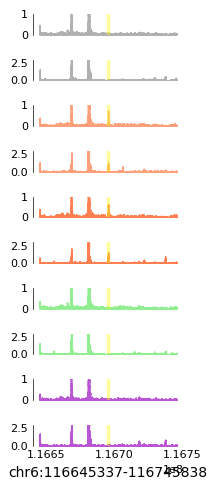

In [515]:
locus_dict = {k: v[index] for k, v in vals_dict.items()}
plot_tracks(
    locus_dict, 
    {"chrom": chrom, "start": start, "end": end}, 
    colors=colors_dict, 
    height=0.5, 
    width=2.25, 
    ylims=y_lims,
    sharey=False,
    highlights=[(top_peaks.iloc[index]["start"]-500, top_peaks.iloc[index]["end"]+500)],
    highlight_colors=["yellow"],
    hspace=0.05,
    label=False
)
# Save
plt.savefig("/cellar/users/aklie/projects/igvf/ChromBetaNet/figures/Fig5/Fig5c.pdf", bbox_inches='tight', dpi=300)
#plot_tracks_from_locus(locus, locus_dict, colors=colors_dict, width=5, height=1, sharey=False, ylims=y_lims)

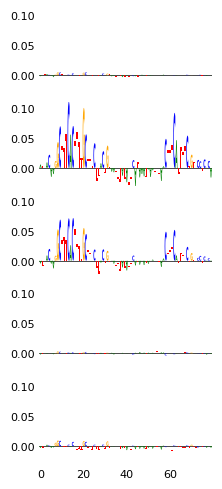

In [524]:
# Plot the contributions across all models for the first locus
fig, axes = plt.subplots(5, 1, figsize=(2.25, 5), sharex=True, sharey=True)
ylim_max = max(
    contrib_dict[k][index].max() for k in contrib_dict.keys()
)
ylim_min = min(
    contrib_dict[k][index].min() for k in contrib_dict.keys()
)
condition_order = ["control", "3-cyt", "IFNg", "Ex-4_HG", "palmitate"]
for i, condition in enumerate(condition_order):
    k = f"{celltype}_{condition}_contribs"
    v = contrib_dict[k]
    plot_logo(
        v[index], 
        ax=axes[i], 
        start=1057+10, 
        end=1057+90,
    )
    # Set ylims to be the same for all axes
    axes[i].set_ylim(ylim_min, ylim_max)

plt.tight_layout()
plt.subplots_adjust(hspace=0.1)
plt.savefig("/cellar/users/aklie/projects/igvf/ChromBetaNet/figures/Fig5/Fig5d.pdf", bbox_inches='tight', dpi=300)

In [ ]:
# Order contribs by the magnitude of the contributions by condition_order
condition_order = ["control", "3-cyt", "IFNg", "Ex-4_HG", "palmitate"]
locus_dict = {}
for condition in condition_order:
    locus_dict[f"{celltype}_{condition}_contribs"] = contrib_magnitude_dict[f"{celltype}_{condition}_contribs"][index][450:550]
plot_tracks(
    locus_dict, 
    {"chrom": chrom, "start": top_peaks.iloc[index]["start"], "end": top_peaks.iloc[index]["end"]},
    colors=colors_contrib,
    height=0.5, 
    width=5, 
    sharey=True,
)

# DONE! 

---

In [ ]:
path_deseq2_res = f"/cellar/users/aklie/data/datasets/igvf_sc-islet_10X-Multiome/results/7_differential_analysis/atac/deseq2/pseudobulk/{celltype}/{condition}/deseq2_results.tsv"
res = pd.read_csv(path_deseq2_res, sep="\t")
res["chrom"] = res["feature"].apply(lambda x: x.split(":")[0])
res["start"] = res["feature"].apply(lambda x: int(x.split(":")[1].split("-")[0]))
res["end"] = res["feature"].apply(lambda x: int(x.split(":")[1].split("-")[1]))

In [ ]:

res_filt = res[res["contrast"] == "LRT-condition:timepoint"]
res_filt = res_filt[res_filt["padj"] < 0.05]
res_filt.sort_values("padj", inplace=True)
res_filt = res_filt[res_filt["baseMean"] > 10]
res_filt